# Can a language model simulate a panel of women — and where does it break?

*A narrative walkthrough of four LLM-persona construction methods, surveyed on AI for finding online communities.*

> My Oxford research examined how young women collectively imagine and shape their relationships to algorithmic platforms. This task asks the inverse question: whether language models can credibly simulate those imaginaries back to us — and where they break.

This notebook walks a reviewer top-to-bottom through the study. Each section explains **why** the step exists, not just what the code does. The headline result, established below across five evaluation dimensions, is that **how you build the personas changes the answer you get** — and **no single method is best on every dimension.**

## The decision this informs

A developer is deciding whether to build an AI tool that helps US women (18+) find online communities, and how to design it. The right way to answer is to survey real women; absent that, we ask whether a panel of **LLM personas** can stand in. The catch is that the *construction method* is a hidden variable: a naive prompt, a demographically-weighted panel, a panel of imagined individuals, and a panel grounded in real behavioral data disagree even on identical questions. We make that disagreement measurable.

In [1]:
import sys; sys.path.insert(0, 'src')
import pandas as pd
from IPython.display import Image, display
import evaluate as ev

methods = ['a', 'b', 'c', 'd']
paths = [f'results/raw/method_{m}_full.jsonl' for m in methods]
df = ev.load_results(paths)
options = ev.load_question_options()
age_order = ['18-29', '30-49', '50-64', '65+']
print('loaded', len(df), 'survey responses across methods', sorted(df.method.unique()))

loaded 6000 survey responses across methods ['A', 'B', 'C', 'D']


## The four methods — a deliberate ladder

Each rung adds exactly one variable, so the comparison isolates what that layer buys and what it costs.

- **A — Naive baseline.** One prompt, *"a random US adult woman"*, sampled 100× at temperature 1.0. Tests the base failure mode: does the model collapse to a single "consensus" answer?
- **B — Demographic conditioning.** Each persona gets a demographic profile (age, race/ethnicity, education, income, region) sampled from US Census ACS marginals, as a system prompt.
- **C — Narrative expansion.** The model writes a ~150-word backstory *from* the Method B profile; that narrative becomes the persona.
- **D — Behaviorally grounded.** The Method B profile **plus** five behavioral traits sampled from Pew's published distributions for women, with the narrative anchored to those empirical facts.

Persona IDs are aligned across B/C/D (same seed, same demographics), so the *same* profile can be traced through all three richer methods — which is what lets us compare them fairly.

### Why start with a naive baseline?

Method A exists to show the problem the other methods must solve. If you just ask the model "answer as a random woman" 100 times, does it give you a distribution — or the same answer 100 times? Below: across 1,500 Method A answers, only **3** deviate from the modal answer.

In [2]:
for qid in options:
    vc = df[(df.method=='A') & (df.question_id==qid)].parsed_answer.value_counts().to_dict()
    print(f'{qid}: {vc}')

q1: {'A': 300}
q2: {'D': 300}
q3: {'A': 300}
q4: {'B': 297, 'A': 3}
q5: {'D': 300}


## Figure 1 — Response distribution by method

Stacked option shares, four bars per question (A/B/C/D). This is the raw picture the five dimensions then quantify: A is a solid block (mode collapse); B opens up; C narrows again; D spreads furthest on the hardest questions.

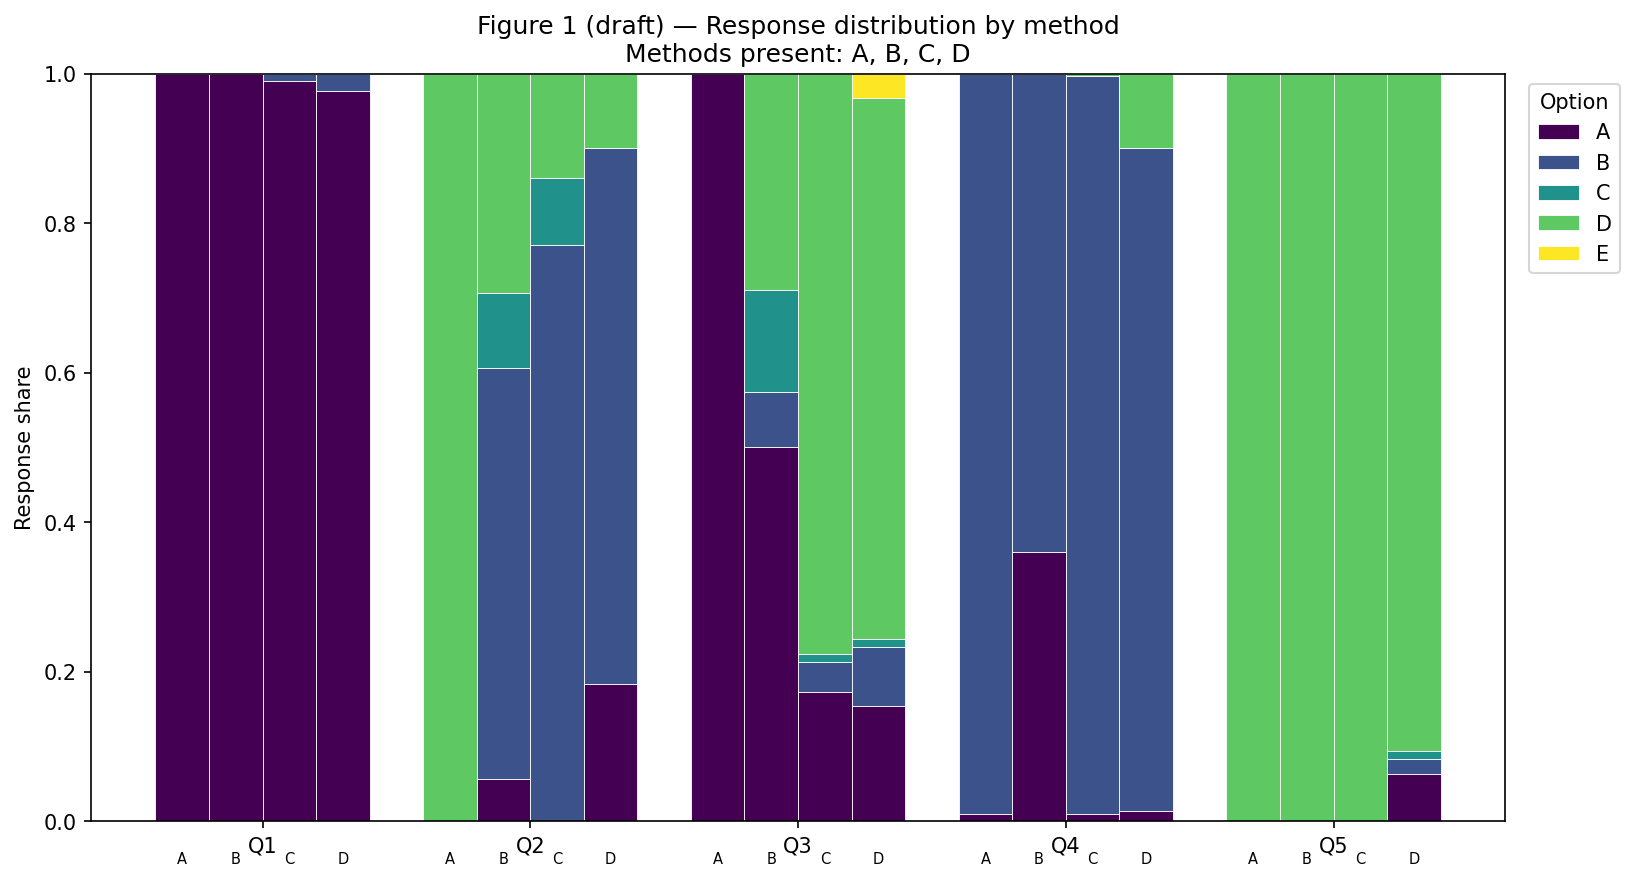

In [3]:
display(Image('results/figures/figure1_response_distribution.png'))

## Dimension 1 — Response diversity (entropy)

**Why entropy?** It is the natural one-number summary of "how much variation did this method produce?" Zero bits = everyone gave the same answer (mode collapse); higher = a real distribution. This is the first thing a decision-maker should ask of a synthetic panel.

In [4]:
ev.entropy_comparison(df, options).round(3)

question,q1,q2,q3,q4,q5
method,,,,,
A,0.000,0.000,0.000,0.081,0.00
B,0.000,1.560,1.687,0.943,0.00
C,0.081,1.000,0.974,0.113,0.00
D,0.160,1.125,1.274,0.569,0.56


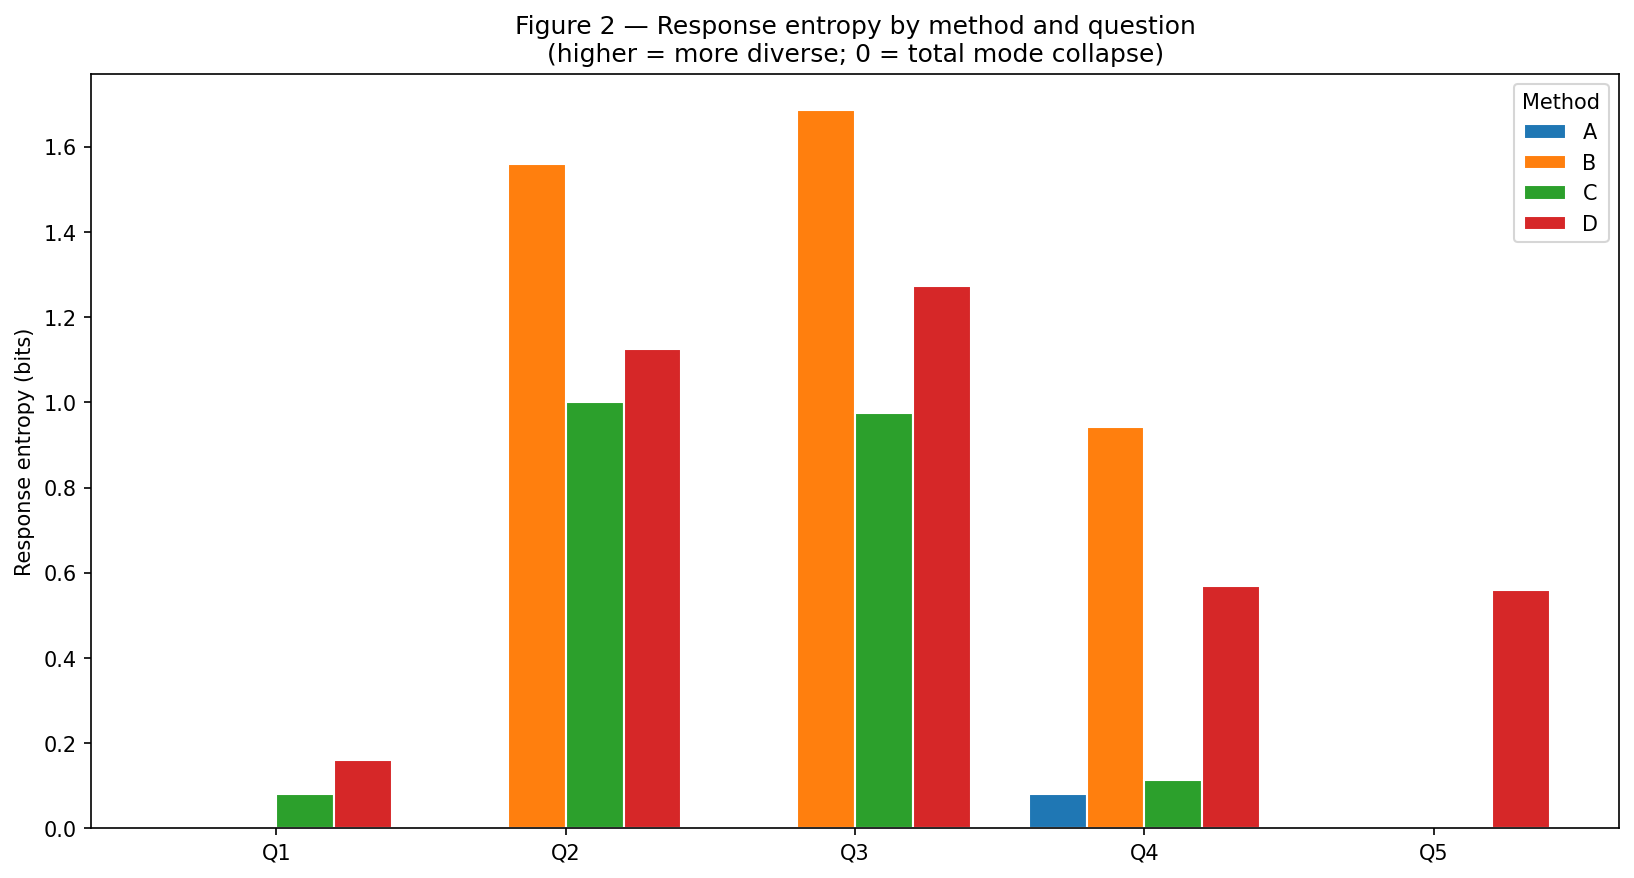

In [5]:
display(Image('results/figures/figure2_entropy_comparison.png'))

Method A is ~0 everywhere. Method B unlocks the most diversity on attitude questions (q2–q4). Method C is *narrower* than B — richer narratives reduced diversity. **Method D is the only method to break collapse on q1 and q5.** The narrative methods don't simply "add" diversity; C trades it away.

## Dimension 2 — Demographic coherence

**Why this matters most for a decision-maker.** A panel is only useful for subgroup questions ("are older women less comfortable?") if subgroups answer in plausible, *differentiated* directions. We split each method's answers by age band on two questions (q3 community type, q2 comfort) to see whether the pattern holds beyond a single question.

In [6]:
for qid in ['q3', 'q2']:
    print(f'=== {qid.upper()} — row % by age band ===')
    for m in ['B', 'C', 'D']:
        print(f'-- Method {m} --')
        display(ev.subgroup_shares(m, qid, options[qid], 'age_band', age_order))

=== Q3 — row % by age band ===
-- Method B --


parsed_answer,A,B,C,D,E
age_band,,,,,
18-29,76,24,0,0,0
30-49,69,11,7,13,0
50-64,49,0,14,38,0
65+,18,0,28,54,0


-- Method C --


parsed_answer,A,B,C,D,E
age_band,,,,,
18-29,41,17,0,43,0
30-49,7,4,4,86,0
50-64,8,0,0,92,0
65+,20,0,0,80,0


-- Method D --


...

parsed_answer,A,B,C,D,E
age_band,,,,,
18-29,0,0,4,96,0
30-49,0,32,27,40,0
50-64,1,92,4,3,0
65+,18,80,2,0,0


-- Method C --


parsed_answer,A,B,C,D,E
age_band,,,,,
18-29,0,24,28,48,0
30-49,0,67,14,19,0
50-64,0,100,0,0,0
65+,0,100,0,0,0


-- Method D --


parsed_answer,A,B,C,D,E
age_band,,,,,
18-29,11,72,0,17,0
30-49,11,79,0,11,0
50-64,26,74,0,0,0
65+,23,63,0,13,0


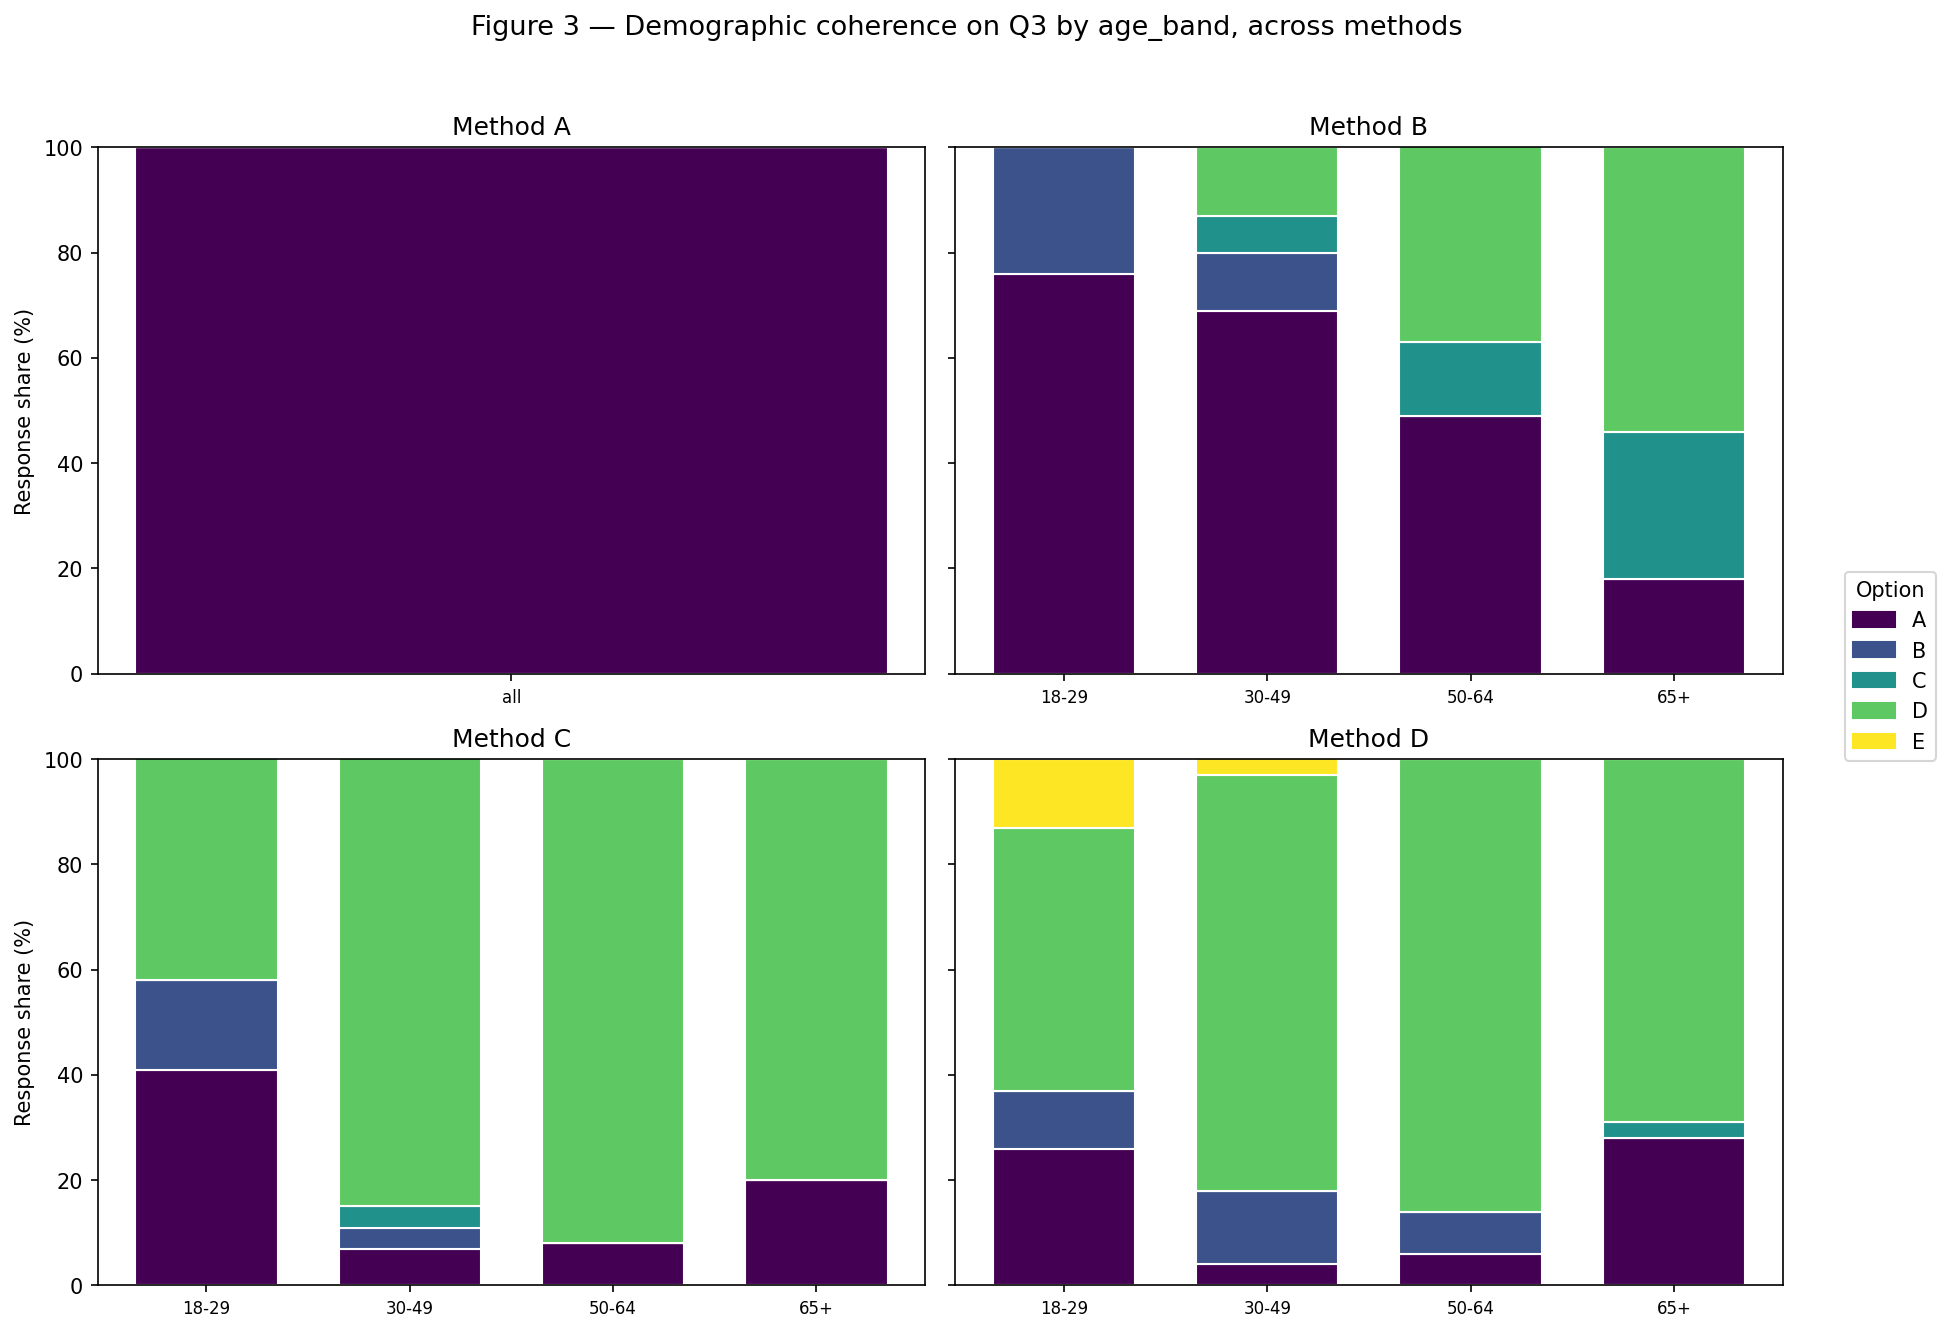

In [7]:
display(Image('results/figures/figure3_demographic_coherence.png'))

**The key finding, replicated across two questions:** only **Method B** holds a clean monotonic age gradient. On q2 comfort, B runs from 96% comfortable (18–29) to 80% *un*comfortable (65+). Method D sits at ~70% "uncomfortable" at *every* age — the gradient is gone. The narratives' vivid "local community" texture overwrites the demographic structure B captured. Richer personas are **not** more demographically representative.

## Dimension 3 — Internal consistency

**Why 3 repeat runs?** A panel you can't reproduce is a panel you can't trust. We ran the same personas through the same questions three times. Distribution stability is high for all methods (modal-share range ≤ 0.07). Test-retest agreement — same persona, identical answer across all 3 reps — shows richer context makes personas *more* deterministic.

In [8]:
display(ev.internal_consistency(df, options))
print('Test-retest agreement (identical answer across all 3 reps, avg over questions):')
for m in ['B', 'C', 'D']:
    print(f'  Method {m}: {ev.test_retest_agreement(m, options):.3f}')
print('  Method A: n/a (independent samples, not fixed personas)')

,method,question,modal_option,modal_share_mean,modal_share_range,per_rep
0,A,q1,A,1.000,0.00,"[1.0, 1.0, 1.0]"
1,A,q2,D,1.000,0.00,"[1.0, 1.0, 1.0]"
2,A,q3,A,1.000,0.00,"[1.0, 1.0, 1.0]"
3,A,q4,B,0.990,0.02,"[0.98, 0.99, 1.0]"
4,A,q5,D,1.000,0.00,"[1.0, 1.0, 1.0]"
5,B,q1,A,1.000,0.00,"[1.0, 1.0, 1.0]"
6,B,q2,B,0.550,0.07,"[0.52, 0.59, 0.54]"
7,B,q3,A,0.500,0.02,"[0.51, 0.49, 0.5]"
8,B,q4,B,0.640,0.03,"[0.63, 0.66, 0.63]"
9,B,q5,D,1.000,0.00,"[1.0, 1.0, 1.0]"


Test-retest agreement (identical answer across all 3 reps, avg over questions):
  Method B: 0.892


  Method C: 0.972


  Method D: 0.964
  Method A: n/a (independent samples, not fixed personas)


C (0.97) and D (0.96) beat B (0.89): a detailed narrative pins a persona's answer more tightly than a bare demographic profile. The 3 reps also double as a reproducibility replicate — re-administering the survey gives near-identical *aggregate* distributions even though individual answers are stochastic.

## Dimension 4 — Behavioral consistency (Method D structural validity)

**Why only Method D?** Only D has *stated* behaviors to check answers against. The structural-validity question: do personas told they hold a behavior answer accordingly? The result depends on whether the trait and the question are aligned.

In [9]:
# stated AI sentiment vs q2 comfort
sent_order = ['more_concerned', 'equally', 'more_excited']
display(ev.trait_shares('D', 'q2', 'ai_sentiment', options['q2'], sent_order))
resp = ev.load_results('results/raw/method_d_full.jsonl')
pers = pd.read_json('results/raw/method_d_personas.jsonl', lines=True)
pers['sent'] = pers['traits'].apply(lambda t: t['ai_sentiment'])
q2 = resp[resp.question_id=='q2'].merge(pers[['persona_id','sent']], on='persona_id')
q2['comfortable'] = q2.parsed_answer.isin(['D','E'])
print('% answering comfortable (D/E) on q2, by stated sentiment:')
print(q2.groupby('sent')['comfortable'].mean().mul(100).round(1).reindex(sent_order).to_string())

parsed_answer,A,B,C,D,E
ai_sentiment,,,,,
more_concerned,30,70,0,0,0
equally,3,84,0,14,0
more_excited,0,0,0,100,0


% answering comfortable (D/E) on q2, by stated sentiment:
sent
more_concerned      0.0
equally            13.5
more_excited      100.0


**Stated sentiment → q2 comfort is clean and monotonic:** more-concerned 0% comfortable, equally 14%, more-excited 100%. By contrast, stated *usage* → q1 was weak (94–100% "Never" regardless), because q1 asks about a niche behavior the usage trait doesn't imply. So the behavioral layer propagates **strongly when the trait matches the question, weakly when it doesn't** — the grounding is only as good as that alignment.

## Dimension 5 — Face validity

**Why judge the narratives?** Diversity and coherence don't tell us whether the personas read as *real people*. We sampled 5 narratives each from C and D and rated them 1–5 on realistic / generic / stereotyped / caricature. The ten narratives and per-rating justifications are in `results/face_validity_narratives.md`.

> ⚠️ **Self-evaluation bias — read before trusting these numbers.** The ratings come from an LLM judge in the **same model family** (`claude-sonnet-4-6`) that wrote the narratives. A model grading its own family's output is **not independent** and very likely skews lenient — a human reader might well rate "generic" or "stereotyped" higher. Dimension 5 is **indicative, not definitive**, and should not be load-bearing on its own. The right next step in a fuller study is **human ratings or a different model-family judge.**

In [10]:
fv = pd.read_csv('results/face_validity_ratings.csv')
display(fv[['method','persona_id','realistic','generic','stereotyped','caricature','justification']])
print('mean ratings per method:')
display(fv.groupby('method')[['realistic','generic','stereotyped','caricature']].mean().round(2))

,method,persona_id,realistic,generic,stereotyped,caricature,justification
0,C,22,4,3,2,1,"Specific details like Fresno, garden center, a..."
1,C,25,4,3,3,1,"Grounded and specific with plausible details, ..."
2,C,48,4,3,3,1,Grounded and specific in places but leans on f...
3,C,51,5,2,2,1,"Specific details like Tucson heat, knees limit..."
4,C,76,5,2,2,1,"Specific geographic details, plausible career,..."
5,D,11,4,3,3,2,Grounded with specific details like Dollar Gen...
6,D,17,5,1,2,1,"Highly specific background, mixed heritage, ec..."
7,D,29,4,2,3,1,Grounded with specific details and nuanced AI ...
8,D,31,4,3,2,1,"Grounded and specific with convincing detail, ..."
9,D,97,5,3,2,1,Specific biographical details and nuanced AI a...


mean ratings per method:


,realistic,generic,stereotyped,caricature
method,,,,
C,4.4,2.6,2.4,1.0
D,4.4,2.4,2.4,1.2


Both methods read as believable (realistic ≈ 4.4) and barely caricatured (≈ 1.1), but the judge repeatedly flags **mild demographic tropes** (Latina-mom, rural-Midwestern-skeptic, Southern-retiree). That trope-leaning is the *same* mechanism that flattens the demographic gradient in dimension 2 — vividness and stereotyping are entangled.

## The same woman, two ways — Method C vs Method D (persona 0)

Persona 0 is the **same demographic profile** in C and D (50–64, White, Bachelor's+, \$30–60k, South). Reading them side by side shows exactly what behavioral grounding adds: C invents a free-form life with no necessary relationship to AI; D's narrative is anchored to *sampled, Pew-sourced* AI attitudes.

In [11]:
c0 = pd.read_json('results/raw/method_c_personas.jsonl', lines=True).set_index('persona_id').loc[0]
d0 = pd.read_json('results/raw/method_d_personas.jsonl', lines=True).set_index('persona_id').loc[0]
print('Shared demographic profile:', c0['profile'])
print()
print('METHOD C — persona 0 (free-form narrative):\n')
print(c0['narrative'])
print('\n' + '-'*70 + '\n')
print('METHOD D — persona 0 (behaviorally grounded)')
print('sampled traits:', d0['traits'], '\n')
print(d0['narrative'])

Shared demographic profile: {'age_band': '50-64', 'race_ethnicity': 'White non-Hispanic', 'education': "Bachelor's degree or higher", 'income': '$30k-$59.9k', 'region': 'South'}

METHOD C — persona 0 (free-form narrative):

I grew up in Knoxville and never strayed too far. I spent twenty years as a dental hygienist, but my hands started giving me trouble, so now I work part-time at the front desk of a pediatric clinic. The pay isn't what it was, but I manage. My daughter's in Nashville, my son's in Charlotte — we text constantly and do Sunday video calls.

Most evenings I'm on the porch with my neighbor Cheryl, drinking sweet tea and talking about nothing important. I go to First Baptist, not because anyone makes me, but because community matters to me. I believe in being straightforward and showing up for people.

Online I'm mostly on Facebook — keeping up with family, sharing recipes, occasionally getting sucked into arguments I regret. I've started using YouTube for gardening tutori

C's persona has *no mention of AI at all* — the narrative is a plausible life, but its relationship to the survey topic is accidental. D's persona foregrounds an explicit, empirically-sourced AI stance (heard a lot → "read plenty"; more concerned → "genuinely worries me"; rare usage → "I don't seek it out"; comfortable → "that feels like enough"). That is the difference between an *imagined* persona and a *grounded* one.

## Five-dimension synthesis

| | A | B | C | D |
|---|---|---|---|---|
| **Diversity** | none (collapse) | **high** | moderate (narrows) | broadest coverage |
| **Demographic coherence** | n/a | **clean gradient** | flattened | flattened |
| **Internal stability** | trivial | 0.89 | **0.97** | 0.96 |
| **Behavioral validity** | n/a | n/a | n/a | **strong (when aligned)** |
| **Face validity** | n/a | n/a | realistic, mild tropes | realistic, mild tropes |

**No method dominates.** The central tension: **B is the most demographically faithful; the narrative methods (esp. D) are richer, more behaviorally grounded, and more stable, but overwrite the demographic gradient** with vivid local-community texture.

## Recommendation & where the panel shouldn't replace humans

**For the community-finder decision:** use **Method D as the primary panel** — strongest structural validity, widest coverage, and its pull toward *local/neighborhood* communities is itself a substantive signal. But **cross-check every demographic-subgroup claim against Method B**, which is the only method that preserves the gradients a subgroup analysis relies on. Treat **A** as a degenerate baseline only — it returns the mode and erases minority opinion.

**Do not** lean on any synthetic panel where the decision hinges on minority opinion, on a behavior no trait was aligned to, or on fine demographic gradients — which is exactly where privacy, surveillance, and discomfort concerns live.

## Limitations

- **Variance flattening / training-data skew** — the panel reflects model priors, not measured humans; A shows the base collapse.
- **Stereotype amplification** — narrative richness leans on mild tropes that overwrite real demographic structure.
- **No external ground truth (by design)** — this is method-vs-method, not method-vs-truth.
- **Face-validity self-eval bias** — same-model-family judge; not independent (see the caveat above).
- **Marginal (not joint) sampling** — cross-variable correlations are not modeled.
- **Model dependence** — all results from `claude-sonnet-4-6`; a second model would test pattern stability.
- **Reproducibility is distributional, not byte-level** — seeded inputs reproduce identically; temperature-1.0 responses do not, by design.

## Future work — networked personas

Drop the independence assumption: place the behaviorally-grounded Method D personas on a small-world social graph, let each see its neighbors' answers in a second round, and measure whether social exposure shifts the panel (convergence, polarization, local norms). This tests the interconnected-persona thesis directly, and community-formation is the precise domain where social context should matter most — people choose communities partly by watching people like them. Out of 48-hour scope to build; in scope to name as the right direction.